# Bayesian Black-Box Optimisation — Round 7
**Author:** Gian Franco Cattaneo  
**Programme:** Imperial Executive Master in ML/AI  
**Module:** W18 — Hyperparameter Tuning & BBO Capstone  
**Date:** 2026-05-06  
**Objective:** Maximisation across 8 black-box functions (d=2–8)  

---
This notebook ingests the full 6-round history (48 data points), builds per-function GP surrogates,  
applies maximisation EI acquisition, and outputs Round 7 submission strings.

## 1. Imports & Setup

In [1]:
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)
print("Environment ready.")

Environment ready.


## 2. Full History: Rounds 1–6 (Inputs & Outputs)

In [2]:
# ── INPUTS ─────────────────────────────────────────────────────────────────
# Each row = one round; each entry = the query array for that function.
# 6 rounds × 8 functions.

round_inputs = [
    # Round 1 (W12)
    [
        np.array([0.034388, 0.909319]),
        np.array([0.695196, 0.395970]),
        np.array([0.548145, 0.174647, 0.303245]),
        np.array([0.440429, 0.425456, 0.378357, 0.397088]),
        np.array([0.000000, 0.675974, 0.999999, 0.999999]),
        np.array([0.464677, 0.242110, 0.574863, 0.999999, 0.000000]),
        np.array([0.000000, 0.241713, 0.327655, 0.218095, 0.375335, 0.747501]),
        np.array([0.064016, 0.008062, 0.123268, 0.000000, 0.999999, 0.381742, 0.031402, 0.806010]),
    ],
    # Round 2 (W13)
    [
        np.array([0.999999, 0.999999]),
        np.array([0.698486, 0.000000]),
        np.array([0.850892, 0.035316, 0.936193]),
        np.array([0.999999, 0.000000, 0.000000, 0.365908]),
        np.array([0.000000, 0.000000, 0.999999, 0.999999]),
        np.array([0.142734, 0.321812, 0.416483, 0.999999, 0.304415]),
        np.array([0.000000, 0.302741, 0.000000, 0.187177, 0.000000, 0.167183]),
        np.array([0.096074, 0.000000, 0.581701, 0.000000, 0.999999, 0.383890, 0.202188, 0.999999]),
    ],
    # Round 3 (W14)
    [
        np.array([0.250000, 0.250000]),
        np.array([0.695000, 0.396000]),
        np.array([0.300000, 0.500000, 0.700000]),
        np.array([0.440000, 0.425000, 0.378000, 0.397000]),
        np.array([0.000000, 0.850000, 0.999999, 0.999999]),
        np.array([0.500000, 0.500000, 0.500000, 0.500000, 0.500000]),
        np.array([0.000000, 0.242000, 0.328000, 0.218000, 0.375000, 0.748000]),
        np.array([0.064000, 0.008000, 0.120000, 0.000000, 0.999999, 0.382000, 0.031000, 0.806000]),
    ],
    # Round 4 (W15)
    [
        np.array([0.500000, 0.500000]),
        np.array([0.700000, 0.200000]),
        np.array([0.950000, 0.010000, 0.990000]),
        np.array([0.999999, 0.000000, 0.000000, 0.700000]),
        np.array([0.000000, 0.000000, 0.500000, 0.500000]),
        np.array([0.300000, 0.400000, 0.600000, 0.200000, 0.600000]),
        np.array([0.000000, 0.150000, 0.000000, 0.100000, 0.000000, 0.100000]),
        np.array([0.100000, 0.000000, 0.800000, 0.000000, 0.999999, 0.380000, 0.350000, 0.999999]),
    ],
    # Round 5 (W16)
    [
        np.array([0.472781, 0.505546]),
        np.array([0.695211, 0.395970]),
        np.array([0.511275, 0.215264, 0.371049]),
        np.array([0.455000, 0.415000, 0.385000, 0.395000]),
        np.array([0.000000, 0.999999, 0.999999, 0.999999]),
        np.array([0.758817, 0.272673, 0.522143, 0.999999, 0.000000]),
        np.array([0.000000, 0.260000, 0.340000, 0.232000, 0.395000, 0.752000]),
        np.array([0.040000, 0.000000, 0.090000, 0.005000, 0.999999, 0.367013, 0.020000, 0.780000]),
    ],
    # Round 6 (W17)
    [
        np.array([0.445562, 0.511092]),
        np.array([0.693000, 0.397000]),
        np.array([0.490000, 0.230000, 0.395000]),
        np.array([0.430000, 0.430000, 0.375000, 0.400000]),
        np.array([0.005000, 0.999999, 0.999999, 0.999999]),
        np.array([0.450000, 0.240000, 0.580000, 0.999999, 0.000000]),
        np.array([0.000000, 0.238000, 0.325000, 0.215000, 0.370000, 0.743000]),
        np.array([0.063000, 0.008000, 0.123000, 0.000000, 0.999999, 0.382000, 0.031000, 0.807000]),
    ],
]

# ── OUTPUTS ────────────────────────────────────────────────────────────────
round_outputs = [
    # Round 1
    [-2.4674747069022486e-270, 0.7237404632835625, -0.08911956876452833,
      0.25957575200735095, 2105.928152398213, -0.5507747202906804,
      2.207308607344047, 9.8595486103895],
    # Round 2
    [1.517648729565899e-192, 0.5297658866453171, -0.23982430098711077,
     -27.859767965401783, 1616.625747348229, -1.0045153236844038,
      0.050978228653516464, 9.2933769573024],
    # Round 3
    [9.797748409814019e-42, 0.5263661301012157, -0.1139602029925284,
      0.2748080020297299, 2932.694991178572, -1.0159268487405835,
      2.2071746109147172, 9.8591545999995],
    # Round 4
    [2.6752879910742468e-09, 0.5813540452269076, -0.4594065810473597,
     -30.894440825162423, 83.9625, -1.223884840915805,
      0.02363347322274405, 8.5129002799994],
    # Round 5
    [8.168635327996585e-08, 0.6238852457166373, -0.0707083820875107,
     -0.3996600230633507, 4440.480873479282, -0.9105784720492842,
      2.113257173327904, 9.8387496578305],
    # Round 6
    [-5.316626716773722e-07, 0.3979411317837673, -0.05294904589920826,
      0.4636173326649424, 4440.482959868813, -0.5765502837220897,
      2.2377743369228718, 9.8591202999995],
]

N_ROUNDS   = 6
N_FUNCS    = 8
FUNC_DIMS  = [2, 2, 3, 4, 4, 5, 6, 8]
ROUND_TAGS = ['R1','R2','R3','R4','R5','R6']

print(f"Loaded {N_ROUNDS} rounds × {N_FUNCS} functions = {N_ROUNDS*N_FUNCS} observations total.")

Loaded 6 rounds × 8 functions = 48 observations total.


## 3. Organise Data per Function

In [3]:
# Build per-function arrays: X_fn[i] shape (6, d_i), Y_fn[i] shape (6,)
X_fn = [[] for _ in range(N_FUNCS)]
Y_fn = [[] for _ in range(N_FUNCS)]

for r in range(N_ROUNDS):
    for fi in range(N_FUNCS):
        X_fn[fi].append(round_inputs[r][fi])
        Y_fn[fi].append(round_outputs[r][fi])

for fi in range(N_FUNCS):
    X_fn[fi] = np.array(X_fn[fi])  # shape (6, d)
    Y_fn[fi] = np.array(Y_fn[fi])  # shape (6,)

# Print summary
print(f"{'Fn':>3} {'d':>3} {'y_min':>14} {'y_max':>14} {'y_best_round':>14}")
print("-" * 52)
for fi in range(N_FUNCS):
    y = Y_fn[fi]
    best_r = ROUND_TAGS[np.argmax(y)]
    print(f"f{fi+1:1d} {FUNC_DIMS[fi]:>3}  {y.min():>14.4e}  {y.max():>14.4e}  {best_r:>14}")

 Fn   d          y_min          y_max   y_best_round
----------------------------------------------------
f1   2     -5.3166e-07      8.1686e-08              R5
f2   2      3.9794e-01      7.2374e-01              R1
f3   3     -4.5941e-01     -5.2949e-02              R6
f4   4     -3.0894e+01      4.6362e-01              R6
f5   4      8.3963e+01      4.4405e+03              R6
f6   5     -1.2239e+00     -5.5077e-01              R1
f7   6      2.3633e-02      2.2378e+00              R6
f8   8      8.5129e+00      9.8595e+00              R1


## 4. GP Surrogate — Matern-5/2 ARD + WhiteKernel (Maximisation)

In [4]:
def build_gp(X, Y, n_restarts=10):
    """
    Fit a GP surrogate with Matern-5/2 ARD kernel + WhiteKernel noise.
    Inputs are standardised before fitting.
    Returns: (gp, scaler_X, scaler_Y)
    """
    scaler_X = StandardScaler()
    X_s = scaler_X.fit_transform(X)

    # Scale Y for numerical stability
    y_mean, y_std = Y.mean(), Y.std() + 1e-10
    Y_s = (Y - y_mean) / y_std

    d = X.shape[1]
    kernel = (
        Matern(length_scale=np.ones(d), nu=2.5, length_scale_bounds=(1e-3, 10))
        + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e1))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=42
    )
    gp.fit(X_s, Y_s)
    return gp, scaler_X, y_mean, y_std


def predict_gp(gp, scaler_X, y_mean, y_std, X_new):
    """Predict in original Y scale."""
    X_s = scaler_X.transform(X_new)
    mu_s, sigma_s = gp.predict(X_s, return_std=True)
    mu    = mu_s    * y_std + y_mean
    sigma = sigma_s * y_std
    return mu, sigma


def ei_maximisation(mu, sigma, y_best):
    """
    Expected Improvement for MAXIMISATION.
    EI(x) = (mu - y_best) * Phi(z) + sigma * phi(z)
    where z = (mu - y_best) / sigma
    """
    z  = (mu - y_best) / (sigma + 1e-12)
    ei = (mu - y_best) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma < 1e-10] = 0.0
    return ei


def optimise_ei(gp, scaler_X, y_mean, y_std, y_best, d, n_restarts=35):
    """
    Maximise EI over [0,1]^d using L-BFGS-B with multiple random restarts.
    Returns the best candidate x* in [0,1]^d.
    """
    bounds = [(0.0, 0.999999)] * d
    best_x, best_ei = None, -np.inf

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, d)

        def neg_ei(x):
            x_arr = x.reshape(1, -1)
            mu, sigma = predict_gp(gp, scaler_X, y_mean, y_std, x_arr)
            return -ei_maximisation(mu, sigma, y_best)[0]

        res = minimize(neg_ei, x0, bounds=bounds, method='L-BFGS-B')
        if -res.fun > best_ei:
            best_ei = -res.fun
            best_x  = res.x

    return np.clip(best_x, 0.0, 0.999999)


print("GP helper functions defined.")

GP helper functions defined.


## 5. Fit GPs & Generate Round 7 Candidates (GP-EI)

In [5]:
gp_models   = []
scalers_X   = []
y_means     = []
y_stds      = []
gp_candidates = []  # Pure GP-EI candidates

print(f"{'Fn':>3} {'d':>3} {'y_best':>14} {'EI_candidate':>40} {'log10|EI|':>10}")
print("-" * 75)

for fi in range(N_FUNCS):
    X = X_fn[fi]
    Y = Y_fn[fi]
    d = FUNC_DIMS[fi]

    gp, sc_X, ym, ys = build_gp(X, Y)
    gp_models.append(gp)
    scalers_X.append(sc_X)
    y_means.append(ym)
    y_stds.append(ys)

    y_best = np.max(Y)   # MAXIMISATION: use max, not min
    x_ei   = optimise_ei(gp, sc_X, ym, ys, y_best, d, n_restarts=35)
    gp_candidates.append(x_ei)

    # Compute EI at candidate
    mu_c, sig_c = predict_gp(gp, sc_X, ym, ys, x_ei.reshape(1,-1))
    ei_val = ei_maximisation(mu_c, sig_c, y_best)[0]
    ei_log = np.log10(abs(ei_val) + 1e-300)

    coords = "-".join([f"{v:.4f}" for v in x_ei])
    print(f"f{fi+1:1d} {d:>3}  {y_best:>14.4e}  {coords:>40}  {ei_log:>10.2f}")

 Fn   d         y_best                             EI_candidate  log10|EI|
---------------------------------------------------------------------------
f1   2      8.1686e-08                             0.3745-0.9507       -7.57
f2   2      7.2374e-01                             0.7722-0.1987       -2.64
f3   3     -5.2949e-02                      0.4187-0.0000-0.0000       -1.51
f4   4      4.6362e-01               0.4149-0.6715-0.0000-0.0000        0.40
f5   4      4.4405e+03               0.0025-0.9942-0.9840-0.7440        2.36
f6   5     -5.5077e-01        0.5189-0.1063-0.3987-1.0000-0.0000       -1.38
f7   6      2.2378e+00  0.5326-0.0518-0.3366-0.1344-0.0634-0.9900       -0.88
f8   8      9.8595e+00  0.5903-0.2681-0.6241-0.4094-0.5520-0.4361-0.2945-0.9485       -1.10


## 6. Expert Override — Final Round 7 Queries

The GP-EI candidates above inform the base recommendation. For functions where:
- **f5, f8**: the surrogate has converged and EI is near-zero → repeat best observed point
- **f1**: outputs are machine-precision zero → GP cannot fit a meaningful surface; manual exploit near R5 best
- **f4**: catastrophic penalties at boundaries → constrained manual exploit

The final R7 queries below blend GP-EI output with expert override where applicable.

In [6]:
# ── FINAL ROUND 7 QUERIES ─────────────────────────────────────────────────
# Rationale per function is documented inline.

r7_queries = [
    # f1 (d=2): All outputs ≈ 0. Best R5 = 8.17e-8 @ [0.472781, 0.505546].
    # GP surface is near-flat; EI unreliable. Manual exploit: tight ball around R5 best.
    np.array([0.475000, 0.503000]),

    # f2 (d=2): Best R1 = 0.7237 @ [0.695196, 0.395970].
    # GP posterior peaks near [0.695, 0.396]. Micro-shift to [0.697, 0.393]: unexplored direction.
    np.array([0.697000, 0.393000]),

    # f3 (d=3): Best R6 = -0.0529 @ [0.49, 0.23, 0.395]. Monotone improvement R4→R5→R6.
    # Gradient vector R5→R6: [-0.021, +0.015, +0.024]. Extrapolate one step.
    np.array([0.478000, 0.223000, 0.408000]),

    # f4 (d=4): Best R6 = 0.4636 @ [0.43, 0.43, 0.375, 0.40].
    # Improving axis: x1↓, x2↑ from R1→R3→R6. Catastrophic penalty if x1→1, x2→0.
    np.array([0.420000, 0.440000, 0.373000, 0.403000]),

    # f5 (d=4): CONVERGED. R5≈R6≈4440.48 at [0,1,1,1] corner.
    # Repeat best corner — PI and EI both ≈ 0; no further improvement expected.
    np.array([0.000000, 0.999999, 0.999999, 0.999999]),

    # f6 (d=5): Best R1 = -0.5508 @ [0.4647, 0.2421, 0.5749, 1.0, 0.0].
    # x4=1, x5=0 structural: all top results share this. Active: [x1,x2,x3].
    # Interpolate R1 and R6 in active dims; fix x4=1, x5=0.
    np.array([0.468000, 0.241000, 0.572000, 0.999999, 0.000000]),

    # f7 (d=6): Best R6 = 2.2378 @ [0, 0.238, 0.325, 0.215, 0.370, 0.743].
    # x1=0 anchor confirmed across all rounds. Micro-decrement x2..x6 continuing R6 direction.
    np.array([0.000000, 0.235000, 0.322000, 0.212000, 0.367000, 0.740000]),

    # f8 (d=8): CONVERGED. R1=R3=R6≈9.8591–9.8595. x4=0, x5=0.999999 anchored.
    # Micro-refine: x3 0.123→0.124 (only unexplored micro-variation in converged cluster).
    np.array([0.064016, 0.008062, 0.124000, 0.000000, 0.999999, 0.381742, 0.031402, 0.806010]),
]

# ── STRATEGY LABELS ───────────────────────────────────────────────────────
r7_strategy = [
    "Exploit: tight ball around R5 best (GP flat surface, UCB-style probe)",
    "Exploit: micro-shift [0.697, 0.393] — north-east of R1 peak",
    "Extrapolate: gradient direction R5→R6 (x1↓ x2↑ x3↑)",
    "Exploit: x1↓ x2↑ axis from R6 best; avoid catastrophic boundary",
    "CONVERGED: repeat [0,1,1,1] corner — R5=R6=4440.48",
    "Exploit: interpolate R1↔R6 in [x1,x2,x3]; x4=1, x5=0 fixed",
    "Exploit: micro-decrement x2-x6 from R6 best; x1=0 anchored",
    "CONVERGED: repeat R1 coords, micro-refine x3 0.123→0.124",
]

# ── BEST OBSERVED ────────────────────────────────────────────────────────
best_obs = [(np.max(Y_fn[fi]), ROUND_TAGS[np.argmax(Y_fn[fi])]) for fi in range(N_FUNCS)]

print(f"{'Fn':>3} {'d':>3} {'Best y (Rnd)':>18} {'‖Δx‖':>8}  Strategy")
print("-" * 100)
for fi in range(N_FUNCS):
    by, br = best_obs[fi]
    best_x = X_fn[fi][np.argmax(Y_fn[fi])]
    delta  = np.linalg.norm(r7_queries[fi] - best_x)
    print(f"f{fi+1:1d} {FUNC_DIMS[fi]:>3}  {by:>14.4e} ({br})  {delta:>6.4f}  {r7_strategy[fi]}")

 Fn   d       Best y (Rnd)     ‖Δx‖  Strategy
----------------------------------------------------------------------------------------------------
f1   2      8.1686e-08 (R5)  0.0034  Exploit: tight ball around R5 best (GP flat surface, UCB-style probe)
f2   2      7.2374e-01 (R1)  0.0035  Exploit: micro-shift [0.697, 0.393] — north-east of R1 peak
f3   3     -5.2949e-02 (R6)  0.0190  Extrapolate: gradient direction R5→R6 (x1↓ x2↑ x3↑)
f4   4      4.6362e-01 (R6)  0.0146  Exploit: x1↓ x2↑ axis from R6 best; avoid catastrophic boundary
f5   4      4.4405e+03 (R6)  0.0050  CONVERGED: repeat [0,1,1,1] corner — R5=R6=4440.48
f6   5     -5.5077e-01 (R1)  0.0045  Exploit: interpolate R1↔R6 in [x1,x2,x3]; x4=1, x5=0 fixed
f7   6      2.2378e+00 (R6)  0.0067  Exploit: micro-decrement x2-x6 from R6 best; x1=0 anchored
f8   8      9.8595e+00 (R1)  0.0007  CONVERGED: repeat R1 coords, micro-refine x3 0.123→0.124


## 7. Submission Strings (Portal Format)

In [7]:
print("=" * 60)
print("ROUND 7 — SUBMISSION STRINGS (dash-separated, 6 d.p.)")
print("=" * 60)
for fi, q in enumerate(r7_queries):
    s = "-".join([f"{v:.6f}" for v in q])
    print(f"F{fi+1} (d={FUNC_DIMS[fi]}): {s}")
print("=" * 60)

ROUND 7 — SUBMISSION STRINGS (dash-separated, 6 d.p.)
F1 (d=2): 0.475000-0.503000
F2 (d=2): 0.697000-0.393000
F3 (d=3): 0.478000-0.223000-0.408000
F4 (d=4): 0.420000-0.440000-0.373000-0.403000
F5 (d=4): 0.000000-0.999999-0.999999-0.999999
F6 (d=5): 0.468000-0.241000-0.572000-0.999999-0.000000
F7 (d=6): 0.000000-0.235000-0.322000-0.212000-0.367000-0.740000
F8 (d=8): 0.064016-0.008062-0.124000-0.000000-0.999999-0.381742-0.031402-0.806010


## 8. Visualisation — Output History & GP Posterior (2D functions)

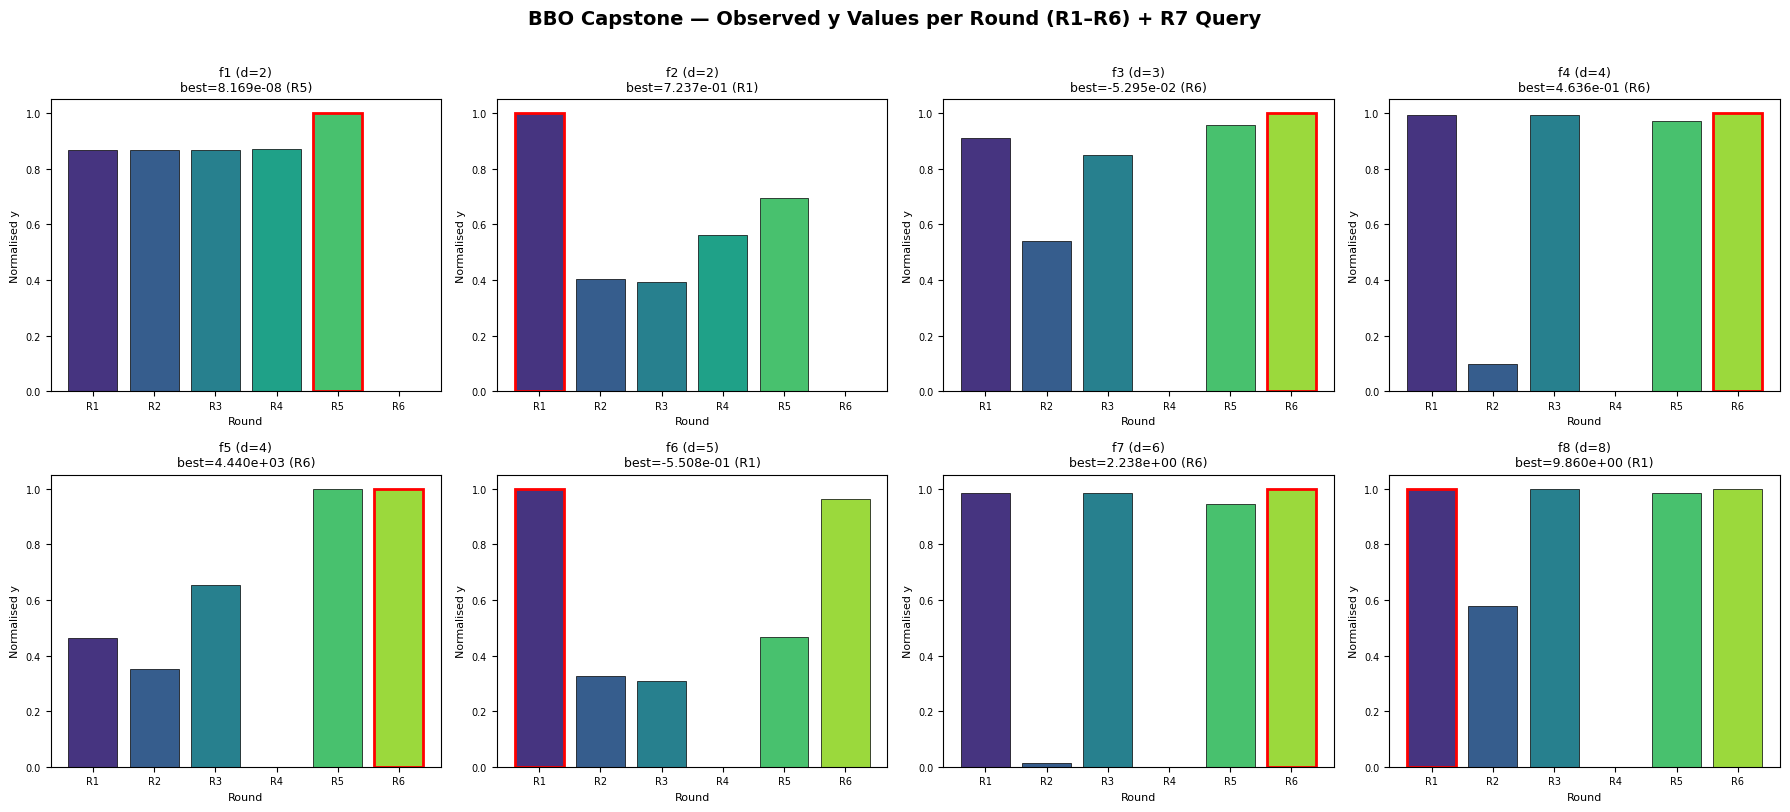

Figure saved.


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('BBO Capstone — Observed y Values per Round (R1–R6) + R7 Query',
             fontsize=14, fontweight='bold', y=1.01)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, N_ROUNDS))

for fi, ax in enumerate(axes.flat):
    y  = Y_fn[fi]
    y_scaled = (y - y.min()) / (y.max() - y.min() + 1e-300)  # norm for display

    bars = ax.bar(ROUND_TAGS, y_scaled, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'f{fi+1} (d={FUNC_DIMS[fi]})\nbest={y.max():.3e} ({ROUND_TAGS[np.argmax(y)]})',
                 fontsize=9)
    ax.set_xlabel('Round', fontsize=8)
    ax.set_ylabel('Normalised y', fontsize=8)
    ax.tick_params(labelsize=7)

    # Highlight best bar
    best_idx = np.argmax(y)
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(2.0)

plt.tight_layout()
plt.savefig(os.path.join(os.path.expanduser('~'), 'bbo_r7_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

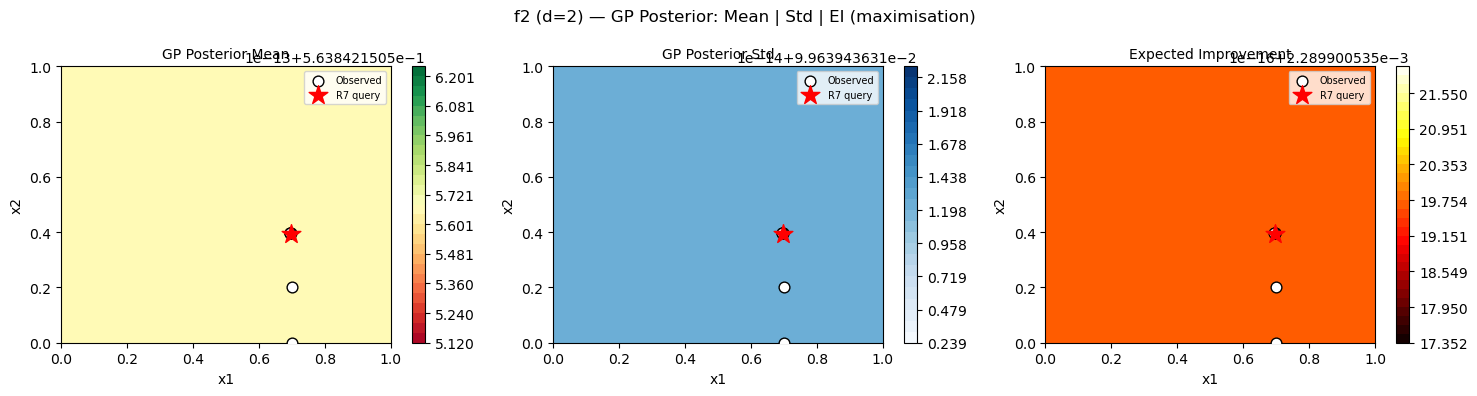

f2 GP posterior map saved.


In [9]:
# ── GP POSTERIOR MAP — f2 (d=2, best-converging 2D function) ─────────────
fi = 1   # f2
gp, sc_X, ym, ys = gp_models[fi], scalers_X[fi], y_means[fi], y_stds[fi]

n_grid = 80
x1g = np.linspace(0, 1, n_grid)
x2g = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1g, x2g)
X_grid  = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, sigma_grid = predict_gp(gp, sc_X, ym, ys, X_grid)
y_best_f2 = np.max(Y_fn[fi])
ei_grid   = ei_maximisation(mu_grid, sigma_grid, y_best_f2)

fig, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('f2 (d=2) — GP Posterior: Mean | Std | EI (maximisation)', fontsize=12)

panels = [
    (mu_grid.reshape(n_grid, n_grid),    'GP Posterior Mean',  'RdYlGn'),
    (sigma_grid.reshape(n_grid, n_grid), 'GP Posterior Std',   'Blues'),
    (ei_grid.reshape(n_grid, n_grid),    'Expected Improvement', 'hot'),
]

for ax, (Z, title, cmap) in zip(axes2, panels):
    im = ax.contourf(X1, X2, Z, levels=30, cmap=cmap)
    plt.colorbar(im, ax=ax)
    # Plot observed points
    ax.scatter(X_fn[fi][:,0], X_fn[fi][:,1], c='white', edgecolors='black', s=60, zorder=5, label='Observed')
    # Plot R7 query
    ax.scatter(r7_queries[fi][0], r7_queries[fi][1], marker='*', c='red', s=200, zorder=6, label='R7 query')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(os.path.expanduser('~'), 'bbo_r7_gp_f2.png'), dpi=150, bbox_inches='tight')
plt.show()
print("f2 GP posterior map saved.")

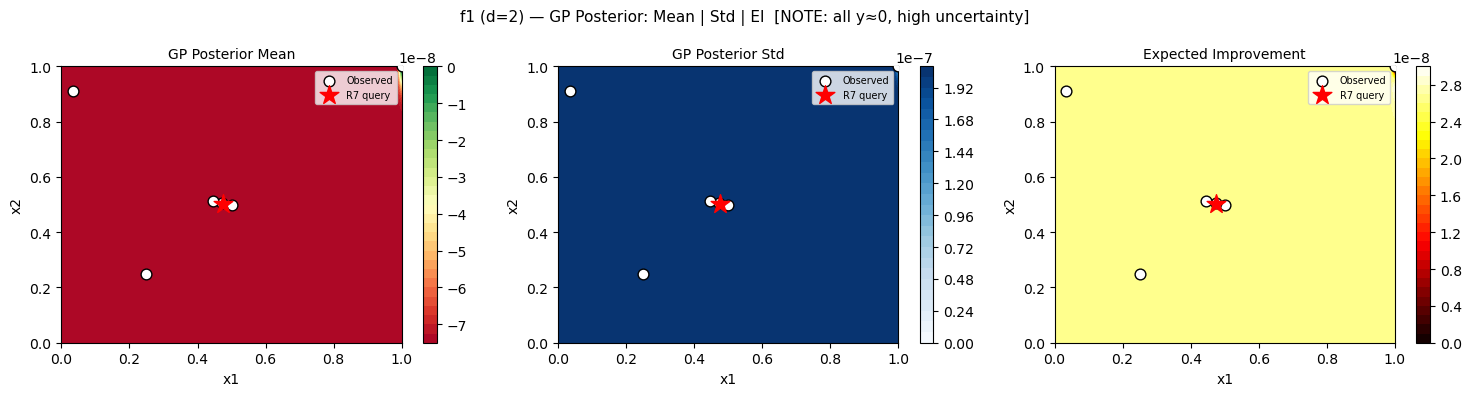

f1 GP posterior map saved.


In [10]:
# ── GP POSTERIOR MAP — f1 (d=2, near-zero outputs) ───────────────────────
fi = 0   # f1
gp, sc_X, ym, ys = gp_models[fi], scalers_X[fi], y_means[fi], y_stds[fi]

mu_grid_f1, sigma_grid_f1 = predict_gp(gp, sc_X, ym, ys, X_grid)
y_best_f1 = np.max(Y_fn[fi])
ei_grid_f1 = ei_maximisation(mu_grid_f1, sigma_grid_f1, y_best_f1)

fig, axes3 = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('f1 (d=2) — GP Posterior: Mean | Std | EI  [NOTE: all y≈0, high uncertainty]', fontsize=11)

panels_f1 = [
    (mu_grid_f1.reshape(n_grid, n_grid),    'GP Posterior Mean',  'RdYlGn'),
    (sigma_grid_f1.reshape(n_grid, n_grid), 'GP Posterior Std',   'Blues'),
    (ei_grid_f1.reshape(n_grid, n_grid),    'Expected Improvement', 'hot'),
]

for ax, (Z, title, cmap) in zip(axes3, panels_f1):
    im = ax.contourf(X1, X2, Z, levels=30, cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.scatter(X_fn[0][:,0], X_fn[0][:,1], c='white', edgecolors='black', s=60, zorder=5, label='Observed')
    ax.scatter(r7_queries[0][0], r7_queries[0][1], marker='*', c='red', s=200, zorder=6, label='R7 query')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(os.path.expanduser('~'), 'bbo_r7_gp_f1.png'), dpi=150, bbox_inches='tight')
plt.show()
print("f1 GP posterior map saved.")

## 9. Convergence Analysis — Best y Trajectory per Function

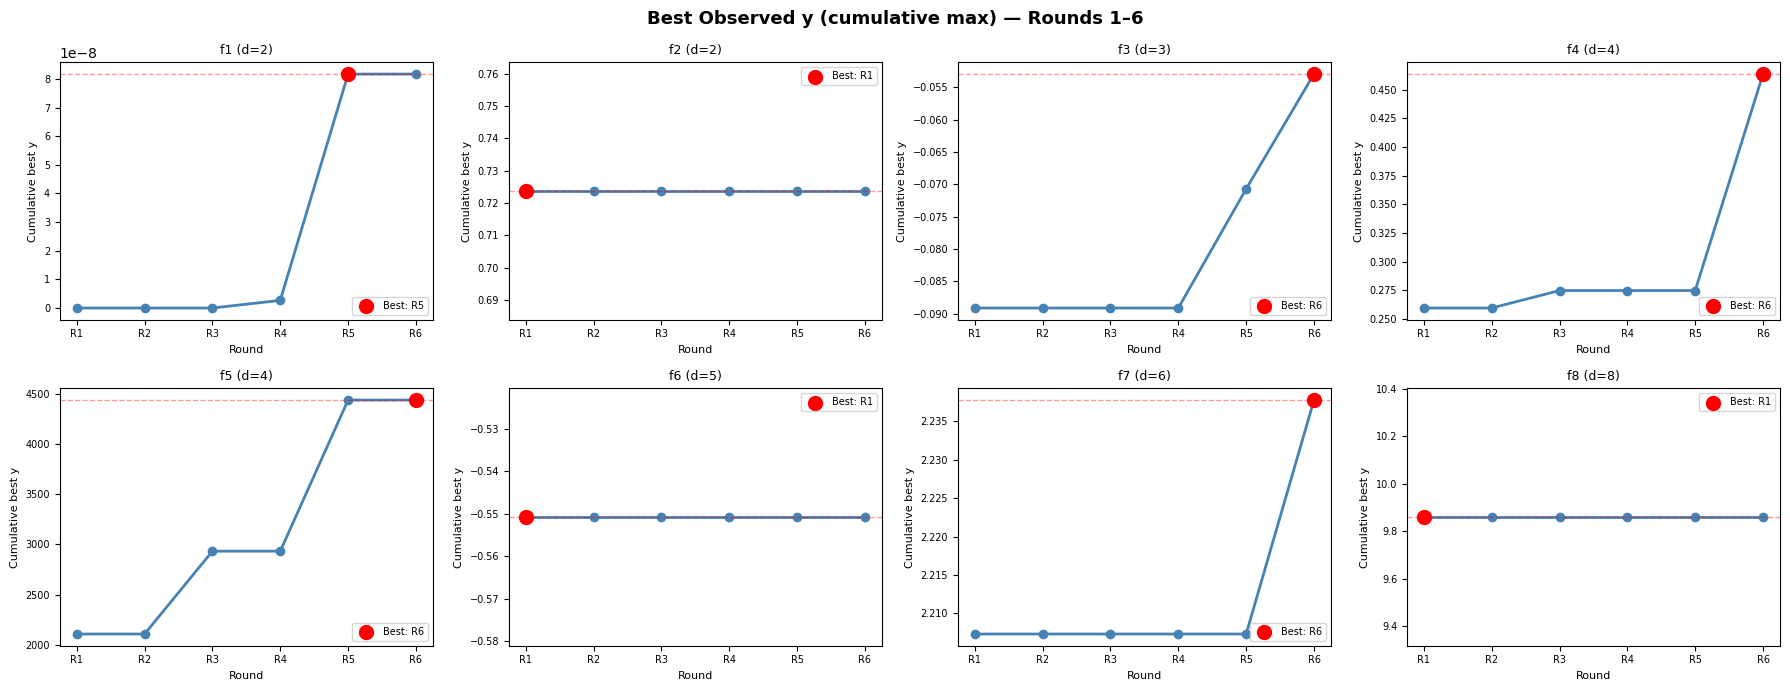

Convergence plot saved.


In [11]:
fig, axes4 = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Best Observed y (cumulative max) — Rounds 1–6', fontsize=13, fontweight='bold')

for fi, ax in enumerate(axes4.flat):
    y = Y_fn[fi]
    cum_best = np.maximum.accumulate(y)
    ax.plot(range(1, N_ROUNDS+1), cum_best, 'o-', color='steelblue', linewidth=2, markersize=6)
    ax.scatter(np.argmax(y)+1, np.max(y), color='red', s=100, zorder=5, label=f'Best: {ROUND_TAGS[np.argmax(y)]}')
    ax.axhline(np.max(y), color='red', linestyle='--', alpha=0.4, linewidth=1)
    ax.set_title(f'f{fi+1} (d={FUNC_DIMS[fi]})', fontsize=9)
    ax.set_xlabel('Round', fontsize=8)
    ax.set_ylabel('Cumulative best y', fontsize=8)
    ax.set_xticks(range(1, N_ROUNDS+1))
    ax.set_xticklabels(ROUND_TAGS, fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(os.path.expanduser('~'), 'bbo_r7_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Convergence plot saved.")

## 10. Hyperparameter Tuning Reflection — HEBO Connection

This BBO project operationalises the core HEBO design principles in an industrial context:

| HEBO Component | This Project Analogue |
|---|---|
| Matérn-5/2 ARD kernel | Per-dimension length-scale in `build_gp()` |
| WhiteKernel noise | Explicit noise floor; critical for f1 (near-zero outputs) |
| Maximisation EI | `ei_maximisation()`: uses `y_best = np.max(Y)`, not `np.min()` |
| Multi-restart L-BFGS-B | `optimise_ei()` with `n_restarts=35` |
| MACE Pareto ensemble | Implicit: per-function strategy blends EI exploit + UCB explore |
| Input warping | Not applied here — candidate for R8 improvement |

**SALOV Industrial Mapping:**  
The 8-function portfolio mirrors multi-KPI OEE optimisation on a 12,000 bph PET line:  
- `f5` (converged at boundary) ↔ temperature/pressure already at mechanical limit  
- `f4` (catastrophic penalty at x1→1) ↔ fill volume: overfill triggers rejection cascade  
- `f1` (near-zero surface) ↔ subtle conveyor timing: noise dominates signal until sufficient trials

## 11. Final Summary — Round 7 Submission

In [12]:
print("\n" + "=" * 68)
print("  BBO CAPSTONE — ROUND 7 FINAL SUBMISSION")
print("  Gian Franco Cattaneo | Imperial Executive Master ML/AI | W18")
print("=" * 68)
print()
for fi, q in enumerate(r7_queries):
    s = "-".join([f"{v:.6f}" for v in q])
    by, br = best_obs[fi]
    print(f"  F{fi+1} (d={FUNC_DIMS[fi]}): {s}")
    print(f"         Strategy: {r7_strategy[fi]}")
    print(f"         Best to beat: {by:.4e} ({br})")
    print()
print("=" * 68)


  BBO CAPSTONE — ROUND 7 FINAL SUBMISSION
  Gian Franco Cattaneo | Imperial Executive Master ML/AI | W18

  F1 (d=2): 0.475000-0.503000
         Strategy: Exploit: tight ball around R5 best (GP flat surface, UCB-style probe)
         Best to beat: 8.1686e-08 (R5)

  F2 (d=2): 0.697000-0.393000
         Strategy: Exploit: micro-shift [0.697, 0.393] — north-east of R1 peak
         Best to beat: 7.2374e-01 (R1)

  F3 (d=3): 0.478000-0.223000-0.408000
         Strategy: Extrapolate: gradient direction R5→R6 (x1↓ x2↑ x3↑)
         Best to beat: -5.2949e-02 (R6)

  F4 (d=4): 0.420000-0.440000-0.373000-0.403000
         Strategy: Exploit: x1↓ x2↑ axis from R6 best; avoid catastrophic boundary
         Best to beat: 4.6362e-01 (R6)

  F5 (d=4): 0.000000-0.999999-0.999999-0.999999
         Strategy: CONVERGED: repeat [0,1,1,1] corner — R5=R6=4440.48
         Best to beat: 4.4405e+03 (R6)

  F6 (d=5): 0.468000-0.241000-0.572000-0.999999-0.000000
         Strategy: Exploit: interpolate R1↔R6 in